<a href="https://colab.research.google.com/github/devarsh3453/NEW/blob/main/ML_L8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Feature Selection for Classification and Regression

## Objective
# To apply different feature selection techniques to classification and regression
# tasks and compare their performance.

## Datasets
# 1. Iris Dataset – Classification
# 2. Boston Housing Dataset – Regression

## Feature Selection Techniques
# 1. SelectKBest
# 2. Recursive Feature Elimination (RFE)
# 3. Lasso-based Feature Selection

## Models
# - Logistic Regression for Iris Classification
# - Linear Regression for Boston Housing Regression

## Evaluation Metrics
# - Accuracy for Classification
# - Mean Squared Error (MSE) and R² Score for Regression

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, fetch_openml

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.feature_selection import (
    SelectKBest,
    f_classif,
    f_regression,
    RFE,
    SelectFromModel
)

from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso

from sklearn.metrics import (
    accuracy_score,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [4]:
iris = load_iris()

X_iris = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y_iris = pd.Series(
    iris.target,
    name="target"
)

print("Iris Dataset Shape:", X_iris.shape)

print("\nFeatures:")
print(X_iris.columns.tolist())

print("\nTarget Classes:")
print(iris.target_names)

print("\nFirst 5 rows:")
display(X_iris.head())

Iris Dataset Shape: (150, 4)

Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Classes:
['setosa' 'versicolor' 'virginica']

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
print("Missing values in Iris:")
print(X_iris.isnull().sum())

print("\nTarget missing values:", y_iris.isnull().sum())

Missing values in Iris:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

Target missing values: 0


In [6]:
boston = fetch_openml(
    name="boston",
    version=1,
    as_frame=True
)

X_boston = boston.data.copy()
y_boston = pd.to_numeric(boston.target)

print("Boston Housing Dataset Shape:", X_boston.shape)

print("\nFeatures:")
print(X_boston.columns.tolist())

print("\nFirst 5 rows:")
display(X_boston.head())

Boston Housing Dataset Shape: (506, 13)

Features:
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

First 5 rows:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33


In [7]:
print("Missing values in Boston Housing:")
print(X_boston.isnull().sum())

print("\nTarget missing values:", y_boston.isnull().sum())

Missing values in Boston Housing:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
dtype: int64

Target missing values: 0


In [8]:
# Handle missing values if present

X_iris = X_iris.fillna(X_iris.mean())
X_boston = X_boston.apply(pd.to_numeric, errors="coerce")
X_boston = X_boston.fillna(X_boston.mean())

print("Iris missing values:", X_iris.isnull().sum().sum())
print("Boston missing values:", X_boston.isnull().sum().sum())

Iris missing values: 0
Boston missing values: 0


In [9]:
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris,
    y_iris,
    test_size=0.30,
    random_state=42,
    stratify=y_iris
)

X_train_boston, X_test_boston, y_train_boston, y_test_boston = train_test_split(
    X_boston,
    y_boston,
    test_size=0.30,
    random_state=42
)

print("Iris:")
print("Training:", X_train_iris.shape)
print("Testing :", X_test_iris.shape)

print("\nBoston Housing:")
print("Training:", X_train_boston.shape)
print("Testing :", X_test_boston.shape)

Iris:
Training: (105, 4)
Testing : (45, 4)

Boston Housing:
Training: (354, 13)
Testing : (152, 13)


In [10]:
results = []

In [11]:
selector_iris_kbest = SelectKBest(
    score_func=f_classif,
    k=2
)

X_train_iris_kbest = selector_iris_kbest.fit_transform(
    X_train_iris,
    y_train_iris
)

X_test_iris_kbest = selector_iris_kbest.transform(
    X_test_iris
)

selected_iris_kbest = X_iris.columns[
    selector_iris_kbest.get_support()
]

print("Selected Iris Features:")
print(selected_iris_kbest.tolist())

Selected Iris Features:
['petal length (cm)', 'petal width (cm)']


In [12]:
iris_kbest_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

iris_kbest_model.fit(
    X_train_iris_kbest,
    y_train_iris
)

y_pred = iris_kbest_model.predict(X_test_iris_kbest)

accuracy = accuracy_score(
    y_test_iris,
    y_pred
)

print("Iris - SelectKBest")
print("Selected Features:", selected_iris_kbest.tolist())
print("Number of Features:", len(selected_iris_kbest))
print("Accuracy:", accuracy)

results.append({
    "Model": "Logistic Regression",
    "Dataset": "Iris",
    "Feature Selection Method": "SelectKBest",
    "Number of Features": len(selected_iris_kbest),
    "Selected Features": ", ".join(selected_iris_kbest),
    "Metric": "Accuracy",
    "Score": accuracy
})

Iris - SelectKBest
Selected Features: ['petal length (cm)', 'petal width (cm)']
Number of Features: 2
Accuracy: 0.9111111111111111


In [13]:
rfe_iris = RFE(
    estimator=LogisticRegression(max_iter=1000),
    n_features_to_select=2
)

X_train_iris_rfe = rfe_iris.fit_transform(
    X_train_iris,
    y_train_iris
)

X_test_iris_rfe = rfe_iris.transform(
    X_test_iris
)

selected_iris_rfe = X_iris.columns[
    rfe_iris.get_support()
]

print("Selected Iris Features using RFE:")
print(selected_iris_rfe.tolist())

Selected Iris Features using RFE:
['petal length (cm)', 'petal width (cm)']


In [14]:
iris_rfe_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

iris_rfe_model.fit(
    X_train_iris_rfe,
    y_train_iris
)

y_pred = iris_rfe_model.predict(
    X_test_iris_rfe
)

accuracy = accuracy_score(
    y_test_iris,
    y_pred
)

print("Iris - RFE")
print("Selected Features:", selected_iris_rfe.tolist())
print("Number of Features:", len(selected_iris_rfe))
print("Accuracy:", accuracy)

results.append({
    "Model": "Logistic Regression",
    "Dataset": "Iris",
    "Feature Selection Method": "RFE",
    "Number of Features": len(selected_iris_rfe),
    "Selected Features": ", ".join(selected_iris_rfe),
    "Metric": "Accuracy",
    "Score": accuracy
})

Iris - RFE
Selected Features: ['petal length (cm)', 'petal width (cm)']
Number of Features: 2
Accuracy: 0.9111111111111111


In [15]:
lasso_iris = SelectFromModel(
    LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=1.0,
        max_iter=1000
    ),
    threshold="mean"
)

X_train_iris_lasso = lasso_iris.fit_transform(
    X_train_iris,
    y_train_iris
)

X_test_iris_lasso = lasso_iris.transform(
    X_test_iris
)

selected_iris_lasso = X_iris.columns[
    lasso_iris.get_support()
]

print("Selected Iris Features using L1:")
print(selected_iris_lasso.tolist())

Selected Iris Features using L1:
['sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [16]:
iris_lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

iris_lasso_model.fit(
    X_train_iris_lasso,
    y_train_iris
)

y_pred = iris_lasso_model.predict(
    X_test_iris_lasso
)

accuracy = accuracy_score(
    y_test_iris,
    y_pred
)

print("Iris - L1 Feature Selection")
print("Selected Features:", selected_iris_lasso.tolist())
print("Number of Features:", len(selected_iris_lasso))
print("Accuracy:", accuracy)

results.append({
    "Model": "Logistic Regression",
    "Dataset": "Iris",
    "Feature Selection Method": "L1 Logistic Regression",
    "Number of Features": len(selected_iris_lasso),
    "Selected Features": ", ".join(selected_iris_lasso),
    "Metric": "Accuracy",
    "Score": accuracy
})

Iris - L1 Feature Selection
Selected Features: ['sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Number of Features: 3
Accuracy: 0.9111111111111111


In [17]:
selector_boston_kbest = SelectKBest(
    score_func=f_regression,
    k=6
)

X_train_boston_kbest = selector_boston_kbest.fit_transform(
    X_train_boston,
    y_train_boston
)

X_test_boston_kbest = selector_boston_kbest.transform(
    X_test_boston
)

selected_boston_kbest = X_boston.columns[
    selector_boston_kbest.get_support()
]

print("Selected Boston Features:")
print(selected_boston_kbest.tolist())

Selected Boston Features:
['INDUS', 'NOX', 'RM', 'TAX', 'PTRATIO', 'LSTAT']


In [18]:
boston_kbest_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

boston_kbest_model.fit(
    X_train_boston_kbest,
    y_train_boston
)

y_pred = boston_kbest_model.predict(
    X_test_boston_kbest
)

mse = mean_squared_error(
    y_test_boston,
    y_pred
)

r2 = r2_score(
    y_test_boston,
    y_pred
)

print("Boston Housing - SelectKBest")
print("Selected Features:", selected_boston_kbest.tolist())
print("Number of Features:", len(selected_boston_kbest))
print("MSE:", mse)
print("R² Score:", r2)

results.append({
    "Model": "Linear Regression",
    "Dataset": "Boston Housing",
    "Feature Selection Method": "SelectKBest",
    "Number of Features": len(selected_boston_kbest),
    "Selected Features": ", ".join(selected_boston_kbest),
    "Metric": "MSE",
    "Score": mse
})

Boston Housing - SelectKBest
Selected Features: ['INDUS', 'NOX', 'RM', 'TAX', 'PTRATIO', 'LSTAT']
Number of Features: 6
MSE: 25.983381053829863
R² Score: 0.6512910803690336


In [19]:
rfe_boston = RFE(
    estimator=LinearRegression(),
    n_features_to_select=6
)

X_train_boston_rfe = rfe_boston.fit_transform(
    X_train_boston,
    y_train_boston
)

X_test_boston_rfe = rfe_boston.transform(
    X_test_boston
)

selected_boston_rfe = X_boston.columns[
    rfe_boston.get_support()
]

print("Selected Boston Features using RFE:")
print(selected_boston_rfe.tolist())

Selected Boston Features using RFE:
['CHAS', 'NOX', 'RM', 'DIS', 'PTRATIO', 'LSTAT']


In [20]:
boston_rfe_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

boston_rfe_model.fit(
    X_train_boston_rfe,
    y_train_boston
)

y_pred = boston_rfe_model.predict(
    X_test_boston_rfe
)

mse = mean_squared_error(
    y_test_boston,
    y_pred
)

r2 = r2_score(
    y_test_boston,
    y_pred
)

print("Boston Housing - RFE")
print("Selected Features:", selected_boston_rfe.tolist())
print("Number of Features:", len(selected_boston_rfe))
print("MSE:", mse)
print("R² Score:", r2)

results.append({
    "Model": "Linear Regression",
    "Dataset": "Boston Housing",
    "Feature Selection Method": "RFE",
    "Number of Features": len(selected_boston_rfe),
    "Selected Features": ", ".join(selected_boston_rfe),
    "Metric": "MSE",
    "Score": mse
})

Boston Housing - RFE
Selected Features: ['CHAS', 'NOX', 'RM', 'DIS', 'PTRATIO', 'LSTAT']
Number of Features: 6
MSE: 22.846586738583923
R² Score: 0.6933883022243372


In [21]:
lasso_boston = SelectFromModel(
    Lasso(alpha=0.1),
    threshold="mean"
)

X_train_boston_lasso = lasso_boston.fit_transform(
    X_train_boston,
    y_train_boston
)

X_test_boston_lasso = lasso_boston.transform(
    X_test_boston
)

selected_boston_lasso = X_boston.columns[
    lasso_boston.get_support()
]

print("Selected Boston Features using Lasso:")
print(selected_boston_lasso.tolist())

Selected Boston Features using Lasso:
['CHAS', 'RM', 'DIS', 'PTRATIO']


In [22]:
boston_lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

boston_lasso_model.fit(
    X_train_boston_lasso,
    y_train_boston
)

y_pred = boston_lasso_model.predict(
    X_test_boston_lasso
)

mse = mean_squared_error(
    y_test_boston,
    y_pred
)

r2 = r2_score(
    y_test_boston,
    y_pred
)

print("Boston Housing - Lasso")
print("Selected Features:", selected_boston_lasso.tolist())
print("Number of Features:", len(selected_boston_lasso))
print("MSE:", mse)
print("R² Score:", r2)

results.append({
    "Model": "Linear Regression",
    "Dataset": "Boston Housing",
    "Feature Selection Method": "Lasso",
    "Number of Features": len(selected_boston_lasso),
    "Selected Features": ", ".join(selected_boston_lasso),
    "Metric": "MSE",
    "Score": mse
})

Boston Housing - Lasso
Selected Features: ['CHAS', 'RM', 'DIS', 'PTRATIO']
Number of Features: 4
MSE: 33.68781453217051
R² Score: 0.5478940409677729


In [23]:
results_df = pd.DataFrame(results)

print("Final Comparison Table")

display(results_df)

Final Comparison Table


,Model,Dataset,Feature Selection Method,Number of Features,Selected Features,Metric,Score
0,Logistic Regression,Iris,SelectKBest,2,"petal length (cm), petal width (cm)",Accuracy,0.911111
1,Logistic Regression,Iris,RFE,2,"petal length (cm), petal width (cm)",Accuracy,0.911111
2,Logistic Regression,Iris,L1 Logistic Regression,3,"sepal width (cm), petal length (cm), petal wid...",Accuracy,0.911111
3,Linear Regression,Boston Housing,SelectKBest,6,"INDUS, NOX, RM, TAX, PTRATIO, LSTAT",MSE,25.983381
4,Linear Regression,Boston Housing,RFE,6,"CHAS, NOX, RM, DIS, PTRATIO, LSTAT",MSE,22.846587
5,Linear Regression,Boston Housing,Lasso,4,"CHAS, RM, DIS, PTRATIO",MSE,33.687815


In [27]:
print("IRIS CLASSIFICATION RESULTS")

iris_results = results_df[
    results_df["Dataset"] == "Iris"
]

display(iris_results)
print("BOSTON HOUSING REGRESSION RESULTS")

boston_results = results_df[
    results_df["Dataset"] == "Boston Housing"
]

display(boston_results)

IRIS CLASSIFICATION RESULTS


,Model,Dataset,Feature Selection Method,Number of Features,Selected Features,Metric,Score
0,Logistic Regression,Iris,SelectKBest,2,"petal length (cm), petal width (cm)",Accuracy,0.911111
1,Logistic Regression,Iris,RFE,2,"petal length (cm), petal width (cm)",Accuracy,0.911111
2,Logistic Regression,Iris,L1 Logistic Regression,3,"sepal width (cm), petal length (cm), petal wid...",Accuracy,0.911111


BOSTON HOUSING REGRESSION RESULTS


,Model,Dataset,Feature Selection Method,Number of Features,Selected Features,Metric,Score
3,Linear Regression,Boston Housing,SelectKBest,6,"INDUS, NOX, RM, TAX, PTRATIO, LSTAT",MSE,25.983381
4,Linear Regression,Boston Housing,RFE,6,"CHAS, NOX, RM, DIS, PTRATIO, LSTAT",MSE,22.846587
5,Linear Regression,Boston Housing,Lasso,4,"CHAS, RM, DIS, PTRATIO",MSE,33.687815


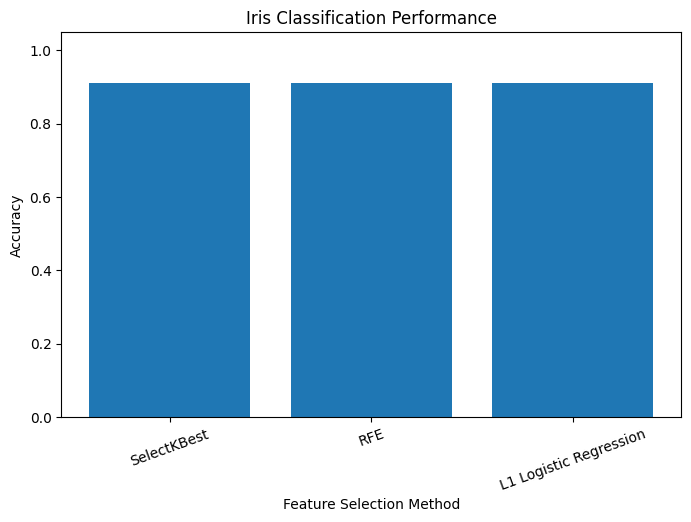

In [28]:
plt.figure(figsize=(8, 5))

plt.bar(
    iris_results["Feature Selection Method"],
    iris_results["Score"]
)

plt.xlabel("Feature Selection Method")
plt.ylabel("Accuracy")
plt.title("Iris Classification Performance")

plt.ylim(0, 1.05)
plt.xticks(rotation=20)

plt.show()

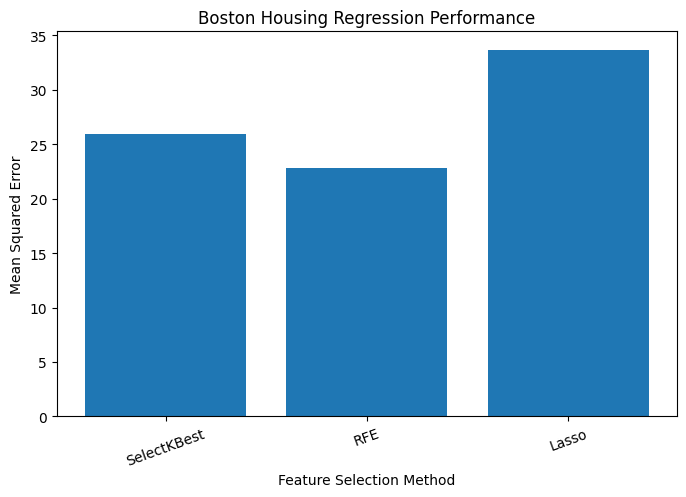

In [29]:
plt.figure(figsize=(8, 5))

plt.bar(
    boston_results["Feature Selection Method"],
    boston_results["Score"]
)

plt.xlabel("Feature Selection Method")
plt.ylabel("Mean Squared Error")
plt.title("Boston Housing Regression Performance")

plt.xticks(rotation=20)

plt.show()


In [30]:
print("IRIS FEATURES")

print("\nSelectKBest:")
print(selected_iris_kbest.tolist())

print("\nRFE:")
print(selected_iris_rfe.tolist())

print("\nL1 Logistic Regression:")
print(selected_iris_lasso.tolist())


print("\n\nBOSTON HOUSING FEATURES")

print("\nSelectKBest:")
print(selected_boston_kbest.tolist())

print("\nRFE:")
print(selected_boston_rfe.tolist())

print("\nLasso:")
print(selected_boston_lasso.tolist())

IRIS FEATURES

SelectKBest:
['petal length (cm)', 'petal width (cm)']

RFE:
['petal length (cm)', 'petal width (cm)']

L1 Logistic Regression:
['sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


BOSTON HOUSING FEATURES

SelectKBest:
['INDUS', 'NOX', 'RM', 'TAX', 'PTRATIO', 'LSTAT']

RFE:
['CHAS', 'NOX', 'RM', 'DIS', 'PTRATIO', 'LSTAT']

Lasso:
['CHAS', 'RM', 'DIS', 'PTRATIO']


In [31]:
print("""
FINAL ANALYSIS

1. SelectKBest selects features based on their statistical relationship
   with the target variable.

2. RFE repeatedly removes less important features and retains the
   features that contribute most to the model.

3. L1-based feature selection uses regularization to reduce the
   importance of less useful features.

4. For the Iris classification task, model performance is evaluated
   using Accuracy.

5. For the Boston Housing regression task, model performance is
   evaluated using Mean Squared Error and R² Score.

6. Feature selection can reduce the number of input features while
   maintaining comparable model performance.

7. The final comparison table allows us to compare the feature
   selection methods based on both the number of selected features
   and model performance.
""")


FINAL ANALYSIS

1. SelectKBest selects features based on their statistical relationship
   with the target variable.

2. RFE repeatedly removes less important features and retains the
   features that contribute most to the model.

3. L1-based feature selection uses regularization to reduce the
   importance of less useful features.

4. For the Iris classification task, model performance is evaluated
   using Accuracy.

5. For the Boston Housing regression task, model performance is
   evaluated using Mean Squared Error and R² Score.

6. Feature selection can reduce the number of input features while
   maintaining comparable model performance.

7. The final comparison table allows us to compare the feature
   selection methods based on both the number of selected features
   and model performance.



In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor

In [25]:
iris_kbest_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

iris_kbest_rf.fit(
    X_train_iris_kbest,
    y_train_iris
)

y_pred = iris_kbest_rf.predict(
    X_test_iris_kbest
)

accuracy = accuracy_score(
    y_test_iris,
    y_pred
)

print("Iris - SelectKBest + Random Forest")
print("Selected Features:", selected_iris_kbest.tolist())
print("Number of Features:", len(selected_iris_kbest))
print("Accuracy:", accuracy)

results.append({
    "Model": "Random Forest",
    "Dataset": "Iris",
    "Feature Selection Method": "SelectKBest",
    "Number of Features": len(selected_iris_kbest),
    "Selected Features": ", ".join(selected_iris_kbest),
    "Metric": "Accuracy",
    "Score": accuracy
})

Iris - SelectKBest + Random Forest
Selected Features: ['petal length (cm)', 'petal width (cm)']
Number of Features: 2
Accuracy: 0.9555555555555556


In [32]:
iris_rfe_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

iris_rfe_rf.fit(
    X_train_iris_rfe,
    y_train_iris
)

y_pred = iris_rfe_rf.predict(
    X_test_iris_rfe
)

accuracy = accuracy_score(
    y_test_iris,
    y_pred
)

print("Iris - RFE + Random Forest")
print("Selected Features:", selected_iris_rfe.tolist())
print("Number of Features:", len(selected_iris_rfe))
print("Accuracy:", accuracy)

results.append({
    "Model": "Random Forest",
    "Dataset": "Iris",
    "Feature Selection Method": "RFE",
    "Number of Features": len(selected_iris_rfe),
    "Selected Features": ", ".join(selected_iris_rfe),
    "Metric": "Accuracy",
    "Score": accuracy
})

Iris - RFE + Random Forest
Selected Features: ['petal length (cm)', 'petal width (cm)']
Number of Features: 2
Accuracy: 0.9555555555555556


In [33]:
iris_lasso_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

iris_lasso_rf.fit(
    X_train_iris_lasso,
    y_train_iris
)

y_pred = iris_lasso_rf.predict(
    X_test_iris_lasso
)

accuracy = accuracy_score(
    y_test_iris,
    y_pred
)

print("Iris - L1 + Random Forest")
print("Selected Features:", selected_iris_lasso.tolist())
print("Number of Features:", len(selected_iris_lasso))
print("Accuracy:", accuracy)

results.append({
    "Model": "Random Forest",
    "Dataset": "Iris",
    "Feature Selection Method": "L1 Logistic Regression",
    "Number of Features": len(selected_iris_lasso),
    "Selected Features": ", ".join(selected_iris_lasso),
    "Metric": "Accuracy",
    "Score": accuracy
})

Iris - L1 + Random Forest
Selected Features: ['sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Number of Features: 3
Accuracy: 0.8888888888888888


In [34]:
boston_kbest_dt = DecisionTreeRegressor(
    random_state=42
)

boston_kbest_dt.fit(
    X_train_boston_kbest,
    y_train_boston
)

y_pred = boston_kbest_dt.predict(
    X_test_boston_kbest
)

mse = mean_squared_error(
    y_test_boston,
    y_pred
)

r2 = r2_score(
    y_test_boston,
    y_pred
)

print("Boston Housing - SelectKBest + Decision Tree")
print("Selected Features:", selected_boston_kbest.tolist())
print("Number of Features:", len(selected_boston_kbest))
print("MSE:", mse)
print("R² Score:", r2)

results.append({
    "Model": "Decision Tree",
    "Dataset": "Boston Housing",
    "Feature Selection Method": "SelectKBest",
    "Number of Features": len(selected_boston_kbest),
    "Selected Features": ", ".join(selected_boston_kbest),
    "Metric": "MSE",
    "Score": mse
})

Boston Housing - SelectKBest + Decision Tree
Selected Features: ['INDUS', 'NOX', 'RM', 'TAX', 'PTRATIO', 'LSTAT']
Number of Features: 6
MSE: 15.952105263157897
R² Score: 0.7859154133701423


In [35]:
boston_rfe_dt = DecisionTreeRegressor(
    random_state=42
)

boston_rfe_dt.fit(
    X_train_boston_rfe,
    y_train_boston
)

y_pred = boston_rfe_dt.predict(
    X_test_boston_rfe
)

mse = mean_squared_error(
    y_test_boston,
    y_pred
)

r2 = r2_score(
    y_test_boston,
    y_pred
)

print("Boston Housing - RFE + Decision Tree")
print("Selected Features:", selected_boston_rfe.tolist())
print("Number of Features:", len(selected_boston_rfe))
print("MSE:", mse)
print("R² Score:", r2)

results.append({
    "Model": "Decision Tree",
    "Dataset": "Boston Housing",
    "Feature Selection Method": "RFE",
    "Number of Features": len(selected_boston_rfe),
    "Selected Features": ", ".join(selected_boston_rfe),
    "Metric": "MSE",
    "Score": mse
})

Boston Housing - RFE + Decision Tree
Selected Features: ['CHAS', 'NOX', 'RM', 'DIS', 'PTRATIO', 'LSTAT']
Number of Features: 6
MSE: 12.740986842105263
R² Score: 0.8290100988959628


In [36]:
boston_lasso_dt = DecisionTreeRegressor(
    random_state=42
)

boston_lasso_dt.fit(
    X_train_boston_lasso,
    y_train_boston
)

y_pred = boston_lasso_dt.predict(
    X_test_boston_lasso
)

mse = mean_squared_error(
    y_test_boston,
    y_pred
)

r2 = r2_score(
    y_test_boston,
    y_pred
)

print("Boston Housing - Lasso + Decision Tree")
print("Selected Features:", selected_boston_lasso.tolist())
print("Number of Features:", len(selected_boston_lasso))
print("MSE:", mse)
print("R² Score:", r2)

results.append({
    "Model": "Decision Tree",
    "Dataset": "Boston Housing",
    "Feature Selection Method": "Lasso",
    "Number of Features": len(selected_boston_lasso),
    "Selected Features": ", ".join(selected_boston_lasso),
    "Metric": "MSE",
    "Score": mse
})

Boston Housing - Lasso + Decision Tree
Selected Features: ['CHAS', 'RM', 'DIS', 'PTRATIO']
Number of Features: 4
MSE: 32.9921052631579
R² Score: 0.5572307792110386


In [37]:
results_df = pd.DataFrame(results)

print("COMPLETE FEATURE SELECTION COMPARISON")

display(results_df)

COMPLETE FEATURE SELECTION COMPARISON


,Model,Dataset,Feature Selection Method,Number of Features,Selected Features,Metric,Score
0,Logistic Regression,Iris,SelectKBest,2,"petal length (cm), petal width (cm)",Accuracy,0.911111
1,Logistic Regression,Iris,RFE,2,"petal length (cm), petal width (cm)",Accuracy,0.911111
2,Logistic Regression,Iris,L1 Logistic Regression,3,"sepal width (cm), petal length (cm), petal wid...",Accuracy,0.911111
3,Linear Regression,Boston Housing,SelectKBest,6,"INDUS, NOX, RM, TAX, PTRATIO, LSTAT",MSE,25.983381
4,Linear Regression,Boston Housing,RFE,6,"CHAS, NOX, RM, DIS, PTRATIO, LSTAT",MSE,22.846587
5,Linear Regression,Boston Housing,Lasso,4,"CHAS, RM, DIS, PTRATIO",MSE,33.687815
6,Random Forest,Iris,SelectKBest,2,"petal length (cm), petal width (cm)",Accuracy,0.955556
7,Random Forest,Iris,RFE,2,"petal length (cm), petal width (cm)",Accuracy,0.955556
8,Random Forest,Iris,L1 Logistic Regression,3,"sepal width (cm), petal length (cm), petal wid...",Accuracy,0.888889
9,Decision Tree,Boston Housing,SelectKBest,6,"INDUS, NOX, RM, TAX, PTRATIO, LSTAT",MSE,15.952105
